# 🏗️ LakeHouse Pipeline - Interactive Notebook

Este notebook permite ejecutar y explorar los Python scripts del proyecto de forma interactiva.

## Configuración del entorno

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [57]:
df=pd.read_csv("../warehouse.csv")

In [ ]:
df.describe()


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307477 entries, 0 to 307643
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307477 non-null  int64  
 1   MONTH             307477 non-null  int64  
 2   SUPPLIER          307477 non-null  object 
 3   ITEM CODE         307477 non-null  object 
 4   ITEM DESCRIPTION  307477 non-null  object 
 5   ITEM TYPE         307477 non-null  object 
 6   RETAIL SALES      307477 non-null  float64
 7   RETAIL TRANSFERS  307477 non-null  float64
 8   WAREHOUSE SALES   307477 non-null  float64
 9   TOTAL_SALES       307477 non-null  float64
 10  PORCENT_RETAIL    307158 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 28.2+ MB


In [58]:
# Dropear solo las filas donde 'SUPPLIER' es nulo
df = df.dropna(subset=['SUPPLIER'])

# Dropear solo las filas donde 'SUPPLIER' es nulo
df = df.dropna(subset=['ITEM TYPE'])

In [60]:
df["TOTAL_SALES"]= df["RETAIL SALES"] + df["WAREHOUSE SALES"]

In [61]:
df["PORCENT_RETAIL"]= df["RETAIL SALES"] / (df["TOTAL_SALES"]+1)

In [70]:
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))

In [71]:
df

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,TOTAL_SALES,PORCENT_RETAIL,DATE
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.00,2.00,0.000000,2020-01-01
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.00,4.00,0.000000,2020-01-01
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.00,1.00,0.000000,2020-01-01
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.00,1.00,0.000000,2020-01-01
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.00,0.82,0.450549,2020-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
307639,2020,9,MILLER BREWING COMPANY,99740,MOLSON GOLDEN 2/12 LNNR - 12OZ,BEER,5.50,9.0,108.50,114.00,0.047826,2020-09-01
307640,2020,9,LEGENDS LTD,99753,DUTCHESS DE BOURGOGNE NR - 750ML,BEER,0.00,0.0,5.00,5.00,0.000000,2020-09-01
307641,2020,9,ANHEUSER BUSCH INC,9997,HOEGAARDEN 4/6NR - 12OZ,BEER,66.12,37.0,240.75,306.87,0.214766,2020-09-01
307642,2020,9,COASTAL BREWING COMPANY LLC,99970,DOMINION OAK BARREL STOUT 4/6 NR - 12OZ,BEER,2.25,0.0,0.00,2.25,0.692308,2020-09-01


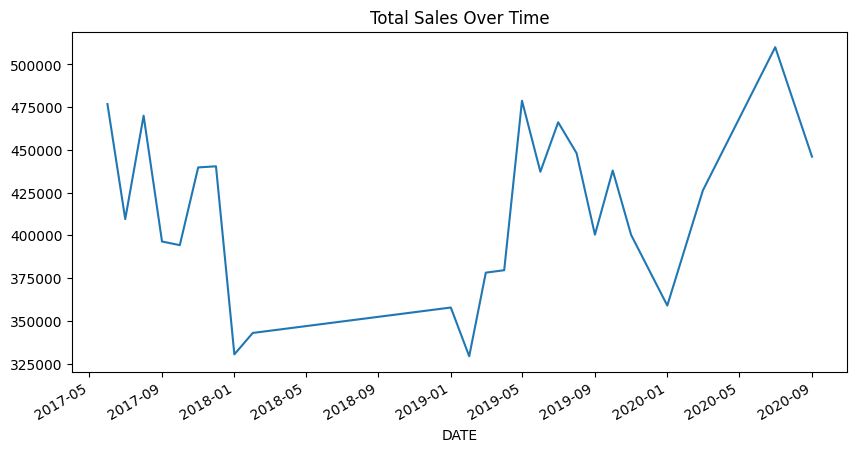

In [ ]:
# Sales Trend Over Time
monthly_sales = df.groupby('DATE')['TOTAL_SALES'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Total Sales Over Time")
plt.show()



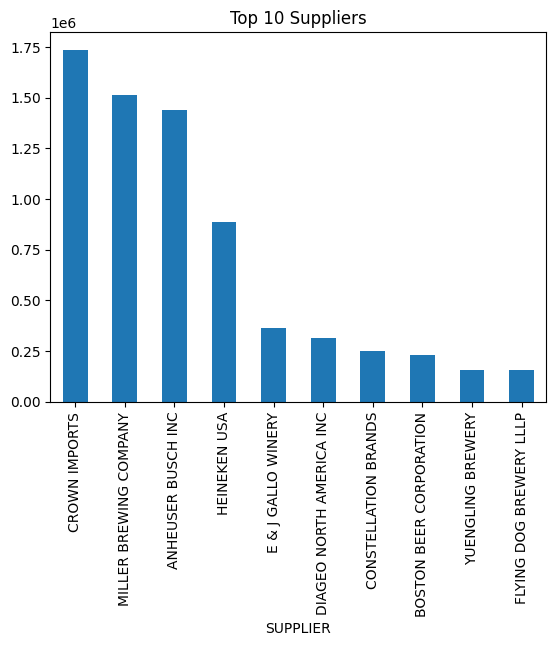

In [77]:
# Top Suppliers
top_suppliers = df.groupby('SUPPLIER')['TOTAL_SALES'].sum().sort_values(ascending=False).head(10)

top_suppliers.plot(kind='bar')
plt.title("Top 10 Suppliers")
plt.show()


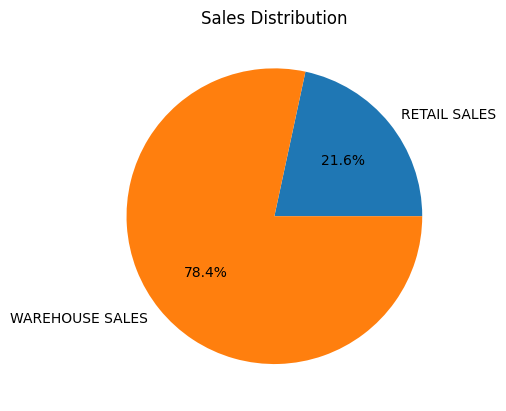

In [78]:
# Retail vs Warehouse Sales
df[['RETAIL SALES','WAREHOUSE SALES']].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution")
plt.show()


In [ ]:
# Transfer Inefficiency 

sns.scatterplot(x='RETAIL TRANSFERS', y='TOTAL_SALES', data=df)
plt.title("Transfers vs Sales")
plt.show()
